<a href="https://colab.research.google.com/github/Olga-Lyt/Analysis_Cafe_Sales/blob/main/21_06_cafe_eda_workbook_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Робочий зошит: Data Cleaning & EDA
## Датасет: Cafe Sales — Dirty Data for Cleaning Training

> **Ваше завдання:** самостійно заповнити всі клітинки з `# ВАШ КОД ТУТ`.
> Підказки є у кожному розділі — але спробуйте спочатку без них!


---
### Структура проєкту
- **Частина 1** — Первинна інспекція (Tasks 1.1–1.3)
- **Частина 2** — Очищення даних (Tasks 2.1–2.4)
- **Частина 3** — EDA та візуалізація (Tasks 3.1–3.5)
- **Частина 4** — Висновки

---

## ⚙️ Підготовка

Завантажте датасет: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Вкажіть шлях до файлу у змінній `FILE_IN` нижче.
Можливі варіанти:
- **Локально:** `FILE_IN = 'data/dirty_cafe_sales.csv'`
- **GitHub Raw URL:** вкажіть посилання на raw-файл
- **Google Colab + Drive:** змонтуйте диск і вкажіть шлях

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# ── Вкажіть шлях до вхідного файлу ──────────────────────────
# FILE_IN = 'data/dirty_cafe_sales.csv'   # локальний варіант
FILE_IN = 'https://raw.githubusercontent.com/Olga-Lyt/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

# ── Вкажіть шлях для збереження чистого файлу ───────────────
# FILE_OUT = 'data/cafe_sales_clean.csv'  # локальний варіант
FILE_OUT = 'cafe_sales_clean.csv'

print('✓ Готово. Починаємо!')

✓ Готово. Починаємо!


---
# ЧАСТИНА 1 — Первинна інспекція

---

## Task 1.1 — Завантаження та перший огляд

**Що потрібно зробити:**
1. Прочитати CSV файл у датафрейм `df`
2. Зберегти оригінал у `df_original` (на випадок якщо щось піде не так)
3. Вивести перші 10 рядків
4. Викликати `.info()` і `.describe(include='all')`

**Зверніть увагу:** які колонки мають тип `object` замість числових? Чому?

In [2]:
# Завантаження датасету
df_origin = pd.read_csv(FILE_IN) # ВАШ КОД ТУТ
df = df_origin.copy()  # ВАШ КОД ТУТ  (копія оригіналу)

print(f'Розмір: 10000 рядків × 8 стовпців')  # замініть ???

# Перші 10 рядків
# ВАШ КОД ТУТ
df.head(10)

Розмір: 10000 рядків × 8 стовпців


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [3]:
# Загальна інформація про датафрейм
# ВАШ КОД ТУТ
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [4]:
# Описова статистика (для числових І текстових колонок)
# Підказка: є параметр include='all'
# ВАШ КОД ТУТ
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


### ✏️ Спостереження після Task 1.1
*(Запишіть тут що ви помітили — підозрілі значення, неправильні типи, тощо)*

- Майже в усіх колонках, крім Transaction ID, пропущені значення. Найбільше пропущених значень в Location та Payment Method.
- В усіх колонках стоїть тип даних object, немає числових даних та дати.
- ...

## Task 1.2 — Дублікати

**Що потрібно зробити:**
1. Порахувати кількість повних дублікатів
2. Видалити дублікати, зберігши перший зустрічний
3. Вивести кількість рядків до і після

**Підказка:** `df.duplicated()`, `df.drop_duplicates(keep=...)`

In [5]:
# Знайти дублікати
n_dupes = df.duplicated().sum() # ВАШ КОД ТУТ
print(f'Знайдено дублікатів: {n_dupes}')
print(f'Рядків до видалення: {len(df)}')

# Видалити дублікати
# ВАШ КОД ТУТ
df.drop_duplicates(inplace=True)

print(f'Рядків після видалення: {len(df)}')


Знайдено дублікатів: 0
Рядків до видалення: 10000
Рядків після видалення: 10000


## Task 1.3 — Аналіз пропущених значень

**Що потрібно зробити:**
1. Замінити значення `'ERROR'`, `'UNKNOWN'`, `''`, `' '` на `np.nan`
2. Порахувати пропуски по кожній колонці (кількість і %)
3. Порахувати загальний % пропусків
4. Побудувати **два** графіки: heatmap і bar chart

**Підказка:** `df.replace(список, np.nan)`, `df.isnull().sum()`

In [6]:
import pandas as pd
import numpy as np

# Re-defining FILE_IN and df for robustness in case of kernel reset
FILE_IN = 'https://raw.githubusercontent.com/Olga-Lyt/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'
df_origin = pd.read_csv(FILE_IN)
df = df_origin.copy()

# Крок 1: замінити 'брудні' значення на NaN
df.replace(['ERROR', 'UNKNOWN', '', ' '], np.nan, inplace=True)

# Крок 2: порахувати пропуски
missing_count = df.isnull().sum() # ВАШ КОД ТУТ
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)  # ВАШ КОД ТУТ  (у відсотках від загальної кількості рядків)

missing_df = pd.DataFrame({'Пропусків': missing_count, '%': missing_pct})

# Показати тільки колонки де є пропуски
print(missing_df[missing_df['Пропусків'] > 0])

# Крок 3: загальний % пропусків
total_pct = (df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100).round(2)
print(f'\nЗагальний % пропусків: {total_pct:.2f}%')

                  Пропусків      %
Item                    969   9.69
Quantity                479   4.79
Price Per Unit          533   5.33
Total Spent             502   5.02
Payment Method         3178  31.78
Location               3961  39.61
Transaction Date        460   4.60

Загальний % пропусків: 12.60%


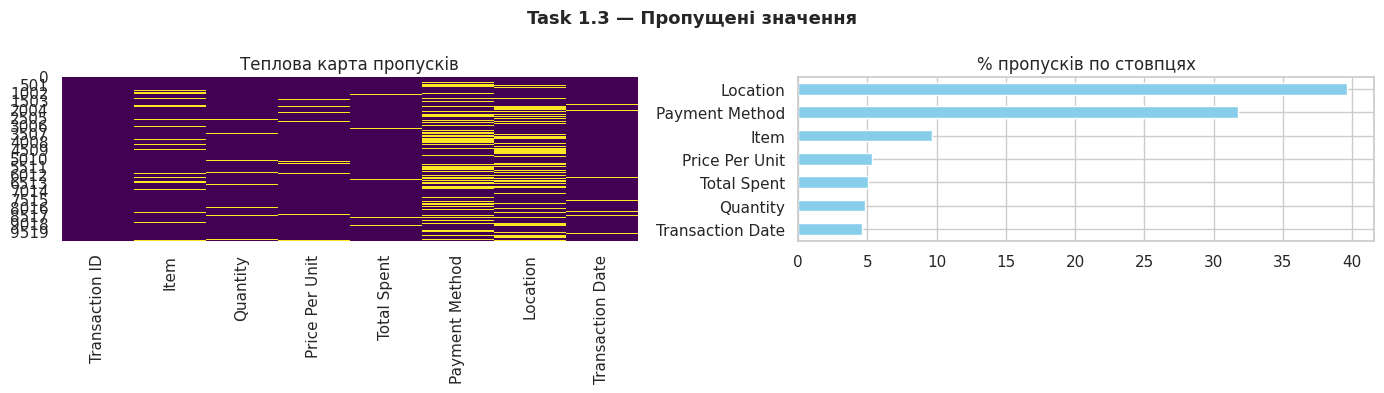

In [7]:
# Крок 4: візуалізація пропусків
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Task 1.3 — Пропущені значення', fontsize=13, fontweight='bold')

# Графік 1: Heatmap пропусків
sns.heatmap(df.isnull(), cbar=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Теплова карта пропусків')

# Графік 2: Horizontal bar chart — % пропусків по колонках
missing_df[missing_df['Пропусків'] > 0].sort_values(by='%', ascending=False)['%'].plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_title('% пропусків по стовпцях')
axes[1].invert_yaxis() # Для відображення найбільших значень зверху

plt.tight_layout()
plt.show()

---
# ЧАСТИНА 2 — Очищення даних

---

## Підготовка: перейменування колонок

Перейменуйте колонки: приберіть пробіли і зробіть назви у форматі `snake_case`.

| Стара назва | Нова назва |
|-------------|------------|
| `Transaction ID` | `transaction_id` |
| `Item` | `item` |
| `Quantity` | `quantity` |
| `Price Per Unit` | `price_per_unit` |
| `Total Spent` | `total_spent` |
| `Payment Method` | `payment_method` |
| `Location` | `location` |
| `Transaction Date` | `transaction_date` |

In [8]:
# Крок 1: прибрати пробіли з назв
df.columns.str.replace(' ', '')

# Крок 2: перейменувати
df = df.rename(columns={
    'TransactionID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'PricePerUnit': 'price_per_unit',
    'TotalSpent': 'total_spent',
    'PaymentMethod': 'payment_method',
    'Location': 'location',
    'TransactionDate': 'transaction_date'
})

print('Нові назви колонок:', list(df.columns))

Нові назви колонок: ['Transaction ID', 'item', 'quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'location', 'Transaction Date']


## Task 2.1 — Обробка пропусків у категорійних колонках

**Стратегії:**

| Колонка | Стратегія |
|---------|----------|
| `transaction_id` | Видалити рядок |
| `item` | По ціні зі словника (якщо є price) → інакше мода |
| `payment_method` | `'Unknown'` — рекомендовано; або мода (варіант Б) |
| `location` | `'Unknown'` — рекомендовано; або мода (варіант Б) |

**Підказки:**
- `df.dropna(subset=[...])` — видалити рядки де NaN у вказаних колонках
- `df['col'].fillna('Unknown')` — заповнити рядком
- Словник і мода для item — виконуються у Task 2.2 після конвертації числових типів

In [10]:
# transaction_id: видалити рядки де NaN
before = len(df)
df.dropna(subset=['Transaction ID'], inplace=True)
print(f'Видалено рядків без transaction_id: {before - len(df)}')

# payment_method:
# Варіант А (рекомендований) — заповнити 'Unknown'
df['Payment Method'].fillna('Unknown', inplace=True)
# Варіант Б — заповнити модою (розкоментуйте)
# mode_pay = df['Payment Method'].mode()[0]
# df['Payment Method'].fillna(mode_pay, inplace=True)

# location:
# Варіант А (рекомендований) — заповнити 'Unknown'
df['location'].fillna('Unknown', inplace=True)
# Варіант Б — заповнити модою (розкоментуйте)
# mode_loc = df['location'].mode()[0]
# df['location'].fillna(mode_loc, inplace=True)

# item: заповнюємо у Task 2.2 після конвертації числових типів
mode_item = df['item'].mode()[0]  # зберігаємо заздалегідь
print(f'Зберегли mode_item = "{mode_item}" для резервного заповнення')

Видалено рядків без transaction_id: 0
Зберегли mode_item = "Juice" для резервного заповнення


## Task 2.2 — Конвертація типів і заповнення item / price / quantity

**Порядок дій:**
1. Конвертувати числові типи (`errors='coerce'`)
2. Побудувати словник `ITEM_PRICE` кодом: `item → мода ціни` з даних
3. **Ситуація 1:** item = NaN, price є → знайти item зі зворотного словника
4. **Ситуація 2:** item є, price = NaN → знайти price зі словника
5. **Ситуація 3:** обидва NaN → item = мода, price = по item
6. **quantity:** якщо є price і total → `qty = total / price`; інакше медіана по товару
7. Відновити `total_spent = qty × price`, перевірити збіг

**Підказки:**
```python
# Побудова словника з даних
df.groupby('item')['price_per_unit'].agg(lambda x: x.mode()[0]).to_dict()
# Зворотний словник
{round(v,2): k for k, v in ITEM_PRICE.items()}
# Медіана по групі
df.groupby('item')['quantity'].transform('median')
```

In [12]:
# Конвертація числових колонок (errors='coerce' → некоректне стає NaN)
df['quantity']         = pd.to_numeric(df['quantity'], errors='coerce')
df['Price Per Unit']   = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent']      = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

print('Типи після конвертації:')
print(df.dtypes)

Типи після конвертації:
Transaction ID              object
item                        object
quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
location                    object
Transaction Date    datetime64[ns]
dtype: object


In [14]:
# Крок 0: будуємо словник ITEM_PRICE з даних (item → мода ціни)
ITEM_PRICE = df.dropna(subset=['item','Price Per Unit']).groupby('item')['Price Per Unit'].agg(lambda x: x.mode()[0]).to_dict()

# Зворотний словник: ціна → товар
PRICE_ITEM = {round(v, 2): k for k, v in ITEM_PRICE.items()}

print(f'Словник побудовано: {len(ITEM_PRICE)} товарів')
print(pd.Series(ITEM_PRICE).sort_index())

Словник побудовано: 8 товарів
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
dtype: float64


In [16]:
# Ситуація 1: item = NaN, price є → знаходимо item по ціні
mask1 = df['item'].isna() & df['Price Per Unit'].notna()
df.loc[mask1, 'item'] = df.loc[mask1, 'Price Per Unit'].round(2).map(PRICE_ITEM)
print(f'Ситуація 1 (є price → item): {mask1.sum()} рядків')

# Ситуація 2: item є, price = NaN → знаходимо ціну по товару
mask2 = df['item'].notna() & df['Price Per Unit'].isna()
df.loc[mask2, 'Price Per Unit'] = df.loc[mask2, 'item'].map(ITEM_PRICE)
print(f'Ситуація 2 (є item → price): {mask2.sum()} рядків')

# Ситуація 3: обидва NaN → item = мода, price = по item
mask3 = df['item'].isna() & df['Price Per Unit'].isna()
mode_item = df['item'].mode()[0]   # рахуємо після заповнення ситуацій 1 і 2
df.loc[mask3, 'item']           = mode_item
df.loc[mask3, 'Price Per Unit'] = ITEM_PRICE.get(mode_item)
print(f'Ситуація 3 (обидва NaN → мода "{mode_item}"): {mask3.sum()} рядків')

print(f'\nNaN у item:           {df["item"].isna().sum()}')
print(f'NaN у Price Per Unit: {df["Price Per Unit"].isna().sum()}')

Ситуація 1 (є price → item): 915 рядків
Ситуація 2 (є item → price): 479 рядків
Ситуація 3 (обидва NaN → мода "Juice"): 54 рядків

NaN у item:           0
NaN у Price Per Unit: 0


In [18]:
# Заповнення quantity
# Варіант А: є price і total_spent → qty = total / price
mask_qty = df['quantity'].isna() & df['Price Per Unit'].notna() & df['Total Spent'].notna()
df.loc[mask_qty, 'quantity'] = (df.loc[mask_qty, 'Total Spent'] / df.loc[mask_qty, 'Price Per Unit']).round()
print(f'quantity відновлено через total/price: {mask_qty.sum()} рядків')

# Варіант Б: решта NaN → медіана по товару
qty_median = df.groupby('item')['quantity'].transform('median')
df['quantity'] = df['quantity'].fillna(qty_median)
df['quantity'] = df['quantity'].round().astype('Int64')
print(f'quantity після медіани по товару: {df["quantity"].isna().sum()} NaN залишилось')

quantity відновлено через total/price: 459 рядків
quantity після медіани по товару: 0 NaN залишилось


In [20]:
mask_total = (
    df['Total Spent'].isna() & df['quantity'].notna() & df['Price Per Unit'].notna()
)
df.loc[mask_total, 'Total Spent'] = df.loc[mask_total, 'quantity'] * df.loc[mask_total, 'Price Per Unit']
print(f'total_spent відновлено (був NaN): {mask_total.sum()} рядків')

# Залишкові NaN total_spent → медіана
df['Total Spent'].fillna(df['Total Spent'].median(), inplace=True)

total_spent відновлено (був NaN): 502 рядків


In [23]:
# Крок 1: порахувати очікуване значення для кожного рядка
df['_expected'] = (df['quantity'] * df['Price Per Unit']).round(2)

# Крок 2: знайти рядки де total_spent не збігається з _expected
mask_mismatch = (df['Total Spent'].round(2) != df['_expected'])
n_mismatch = mask_mismatch.sum()

print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch} рядків')

if n_mismatch > 0:
    # Крок 3: показати перші 5 розбіжностей
    print('\nПерші 5 (до виправлення):')
    print(df.loc[mask_mismatch,
                 ['item','quantity','Price Per Unit','Total Spent','_expected']].head())

    # Крок 4: ПЕРЕЗАПИСАТИ total_spent перерахованим значенням
    df.loc[mask_mismatch, 'Total Spent'] = df.loc[mask_mismatch, '_expected']
    print(f'\n→ total_spent перезаписано для {n_mismatch} рядків')

df.drop(columns=['_expected'], inplace=True)

# Крок 5: фінальна перевірка — розбіжностей має бути 0
still_bad = (df['Total Spent'].round(2) !=
             (df['quantity'].astype(float) * df['Price Per Unit']).round(2)).sum()
print(f'\nФінальна перевірка: {still_bad} розбіжностей залишилось')

# Видалити рядки без дати
before = len(df)
df.dropna(subset=['Transaction Date'], inplace=True)
print(f'Видалено рядків без дати: {before - len(df)}')


Збігів:       10000 / 10000
Розбіжностей: 0 рядків

Фінальна перевірка: 0 розбіжностей залишилось
Видалено рядків без дати: 460


### Перевірка total_spent і рішення про розбіжності

Після відновлення порівняйте `total_spent` з `quantity × price_per_unit`.

Якщо є розбіжності — що з ними робити?

| Ситуація | Рішення |
|----------|---------|
| `total_spent` відновлювався з NaN | Перерахований вже правильний — залишити |
| `qty` або `price` відновлювались (мода/словник) | Перерахований надійніший — **перезаписати** |
| Всі поля були в оригіналі, але не збігаються | Помилка вводу — **перезаписати** |

У нашому проєкті — **перезаписуємо** скрізь де є розбіжність,
бо ціни зі словника надійніші за оригінал.

In [25]:
# Крок 1: порахувати очікуване значення для кожного рядка
df['_expected'] = (df['quantity'] * df['Price Per Unit']).round(2)

# Крок 2: знайти рядки де total_spent не збігається з _expected
mask_mismatch = (df['Total Spent'].round(2) != df['_expected'])
n_mismatch = mask_mismatch.sum()

print(f'Збігів:       {len(df) - n_mismatch} / {len(df)}')
print(f'Розбіжностей: {n_mismatch} рядків')

if n_mismatch > 0:
    # Крок 3: показати перші 5 розбіжностей
    print('\nПерші 5 (до виправлення):')
    print(df.loc[mask_mismatch,
                 ['item','quantity','Price Per Unit','Total Spent','_expected']].head())

    # Крок 4: ПЕРЕЗАПИСАТИ total_spent перерахованим значенням
    df.loc[mask_mismatch, 'Total Spent'] = df.loc[mask_mismatch, '_expected']
    print(f'\n→ total_spent перезаписано для {n_mismatch} рядків')

df.drop(columns=['_expected'], inplace=True);

# Крок 5: фінальна перевірка — розбіжностей має бути 0
still_bad = (df['Total Spent'].round(2) !=
             (df['quantity'].astype(float) * df['Price Per Unit']).round(2)).sum()
print(f'\nФінальна перевірка: {still_bad} розбіжностей залишилось')

# Видалити рядки без дати
before = len(df)
df.dropna(subset=['Transaction Date'], inplace=True)
print(f'Видалено рядків без дати: {before - len(df)}')


Збігів:       9540 / 9540
Розбіжностей: 0 рядків

Фінальна перевірка: 0 розбіжностей залишилось
Видалено рядків без дати: 0


## Task 2.3 — Стандартизація тексту

Приведіть `item`, `payment_method`, `location` до єдиного формату:
- Приберіть зайві пробіли (`.str.strip()`)
- Кожне слово з великої літери (`.str.title()`)

In [27]:
for col in ['item', 'Payment Method', 'location']:
    df[col] = df[col].astype(str).str.strip().str.title()

print('Унікальні payment_method:', sorted(df['Payment Method'].unique()))
print('Унікальні location:',       sorted(df['location'].unique()))

Унікальні payment_method: ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']
Унікальні location: ['In-Store', 'Takeaway', 'Unknown']


## Task 2.4 — Feature Engineering

З колонки `transaction_date` витягніть нові ознаки:

| Нова колонка | Що містить | Підказка |
|-------------|------------|----------|
| `year` | Рік (число) | `.dt.year` |
| `month` | Місяць (число 1–12) | `.dt.month` |
| `month_name` | Назва місяця рядком | `.dt.strftime('%B')` |
| `weekday` | Назва дня тижня | `.dt.day_name()` |
| `is_weekend` | True якщо сб/нд | `.isin(['Saturday', 'Sunday'])` |

In [30]:
df['year']       = df['Transaction Date'].dt.year
df['month']      = df['Transaction Date'].dt.month
df['month_name'] = df['Transaction Date'].dt.strftime('%B')
df['weekday']    = df['Transaction Date'].dt.day_name()
df['week']       = df['Transaction Date'].dt.isocalendar().week.astype('Int64')
df['is_weekend'] = df['Transaction Date'].dt.day_name().isin(['Saturday', 'Sunday'])

# Перевірка логічності
df = df[df['quantity'] > 0]
df = df[df['Total Spent'] > 0]

print(f'✓ Фінальний датасет: {df.shape}')
print('\nПерші рядки з новими колонками:')
df[['Transaction Date', 'year', 'month', 'month_name', 'weekday', 'is_weekend']].head()

✓ Фінальний датасет: (9540, 14)

Перші рядки з новими колонками:


,Transaction Date,year,month,month_name,weekday,is_weekend
0,2023-09-08,2023,9,September,Friday,False
1,2023-05-16,2023,5,May,Tuesday,False
2,2023-07-19,2023,7,July,Wednesday,False
3,2023-04-27,2023,4,April,Thursday,False
4,2023-06-11,2023,6,June,Sunday,True


In [32]:
# Зберегти чистий файл
df_tableau = df.copy()
df_tableau['Transaction Date'] = df_tableau['Transaction Date'].dt.strftime('%Y-%m-%d')
df_tableau['is_weekend'] = df_tableau['is_weekend'].map({True: 'Yes', False: 'No'})
df_tableau.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')
print(f'✓ Збережено: {FILE_OUT} — готовий для Tableau!')

✓ Збережено: cafe_sales_clean.csv — готовий для Tableau!


---
# ЧАСТИНА 3 — EDA

---

## Task 3.1 — Топ товари

**Що потрібно:**
1. Топ-5 товарів за `quantity` (кількість)
2. Топ-5 товарів за `total_spent` (виторг)
3. Два bar chart поруч — один для кожного топу

**Підказка:** `df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)`

In [34]:
# Топ-5 за кількістю
top_qty = df.groupby('item')['quantity'].sum().sort_values(ascending=False).head(5)

# Топ-5 за виторгом
top_rev = df.groupby('item')['Total Spent'].sum().sort_values(ascending=False).head(5)

print('Топ-5 за кількістю:')
print(top_qty.to_string())
print('\nТоп-5 за виторгом:')
print(top_rev.round(2).to_string())

Топ-5 за кількістю:
item
Juice       4200
Smoothie    3831
Coffee      3755
Salad       3646
Tea         3420

Топ-5 за виторгом:
item
Salad       18230.0
Smoothie    15324.0
Sandwich    13116.0
Juice       12600.0
Cake         9843.0


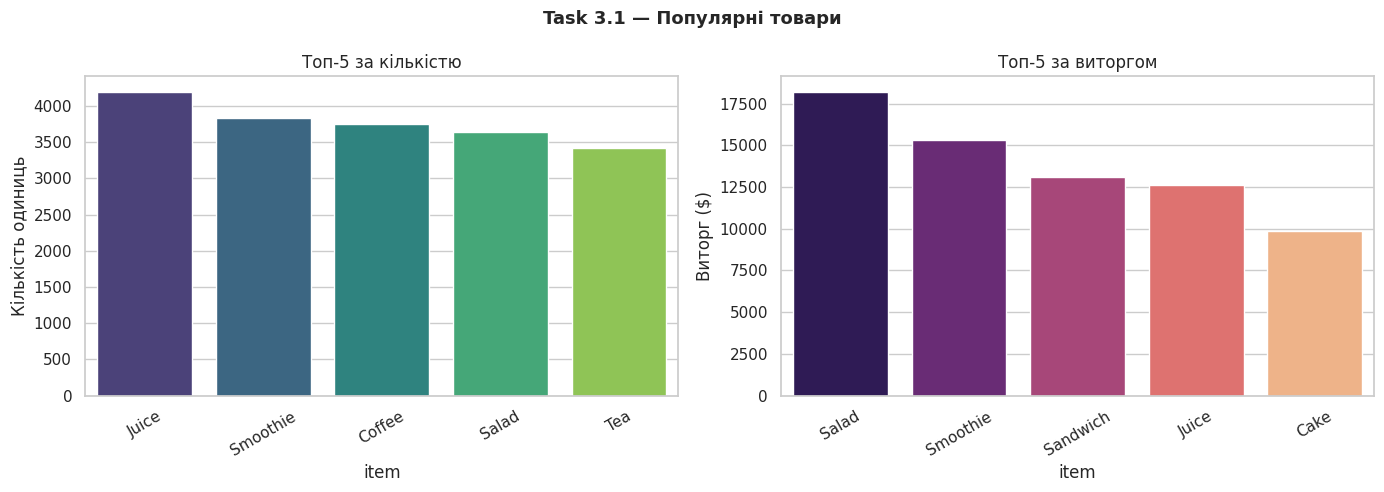

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 3.1 — Популярні товари', fontsize=13, fontweight='bold')

# Графік 1: топ за кількістю
sns.barplot(x=top_qty.index, y=top_qty.values, ax=axes[0], palette='viridis')
axes[0].set_title('Топ-5 за кількістю')
axes[0].set_ylabel('Кількість одиниць')
axes[0].tick_params(axis='x', rotation=30)

# Графік 2: топ за виторгом
sns.barplot(x=top_rev.index, y=top_rev.values, ax=axes[1], palette='magma')
axes[1].set_title('Топ-5 за виторгом')
axes[1].set_ylabel('Виторг ($)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('part3_task31.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.1
*(Що помітили? Чи збігаються топи за кількістю та виторгом?)*  
На двох графіках за кількістю та виторгм збігається тільки друга позиція. В обох графіках її посідає Smoothee. Перше місце в ТОП-5 за кількістю посідає JuiceБ а в ТОП-5 за виторгом Salad.

- ...

## Task 3.2 — Payment Method та Location

**Що потрібно:**
1. Загальний виторг по `payment_method` — pie chart
2. Загальний виторг по `location` — bar chart

**Підказка:** `df.groupby('payment_method')['total_spent'].sum()`

In [37]:
rev_pay = df.groupby('Payment Method')['Total Spent'].sum()
rev_loc = df.groupby('location')['Total Spent'].sum()

print('Виторг по оплаті:')
print(rev_pay.round(2).to_string())
print('\nВиторг по локації:')
print(rev_loc.round(2).to_string())

Виторг по оплаті:
Payment Method
Cash              19571.0
Credit Card       19542.5
Digital Wallet    19605.5
Unknown           26454.0

Виторг по локації:
location
In-Store    25978.0
Takeaway    25455.5
Unknown     33739.5


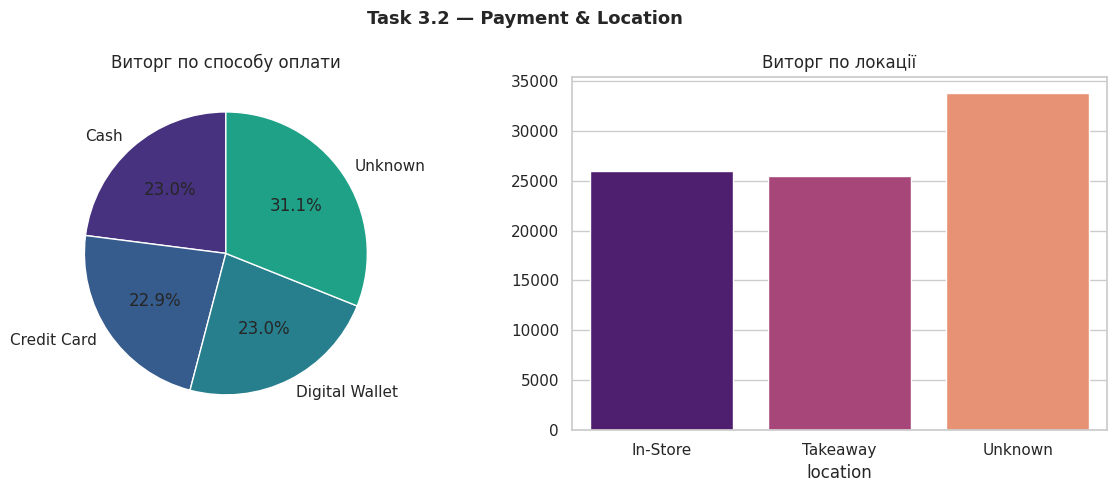

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.2 — Payment & Location', fontsize=13, fontweight='bold')

# Pie chart — payment_method
axes[0].pie(rev_pay, labels=rev_pay.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis'))
axes[0].set_title('Виторг по способу оплати')

# Bar chart — location
sns.barplot(x=rev_loc.index, y=rev_loc.values, ax=axes[1], palette='magma')
axes[1].set_title('Виторг по локації')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('part3_task32.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Висновок до Task 3.2

- Який спосіб оплати домінує: оплата розподілена приблизно рівномірно між трьома способами (близько 23%). Найбільшу частку (31%) становить невизначений спосіб оплати.
- In-store чи Takeaway більше: за виторгом по локації незначна різниця, але In-store замовляли трохи більше, ніж Takeaway.

## Task 3.3 — Часові тренди

**Що потрібно:**
1. Щоденний виторг — лінійний графік
2. Щомісячний виторг — bar chart
3. Середній виторг по днях тижня — bar chart (червоний = вихідні)

**Підказки:**
- `df.groupby('transaction_date')['total_spent'].sum().reset_index()`
- `df.groupby('weekday')['total_spent'].mean().reindex(dow_order)`
- Правильний порядок: `['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']`

In [40]:
# Щоденний виторг
daily_rev = df.groupby('Transaction Date')['Total Spent'].sum()

# Щомісячний виторг
monthly_rev = df.groupby([df['Transaction Date'].dt.year, df['Transaction Date'].dt.month_name()])['Total Spent'].sum()

# По днях тижня (середнє)
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_dow = df.groupby('weekday')['Total Spent'].mean().reindex(dow_order)

print(f'Найкращий день: {avg_dow.idxmax()}')
print(f'Найгірший день: {avg_dow.idxmin()}')

Найкращий день: Tuesday
Найгірший день: Wednesday


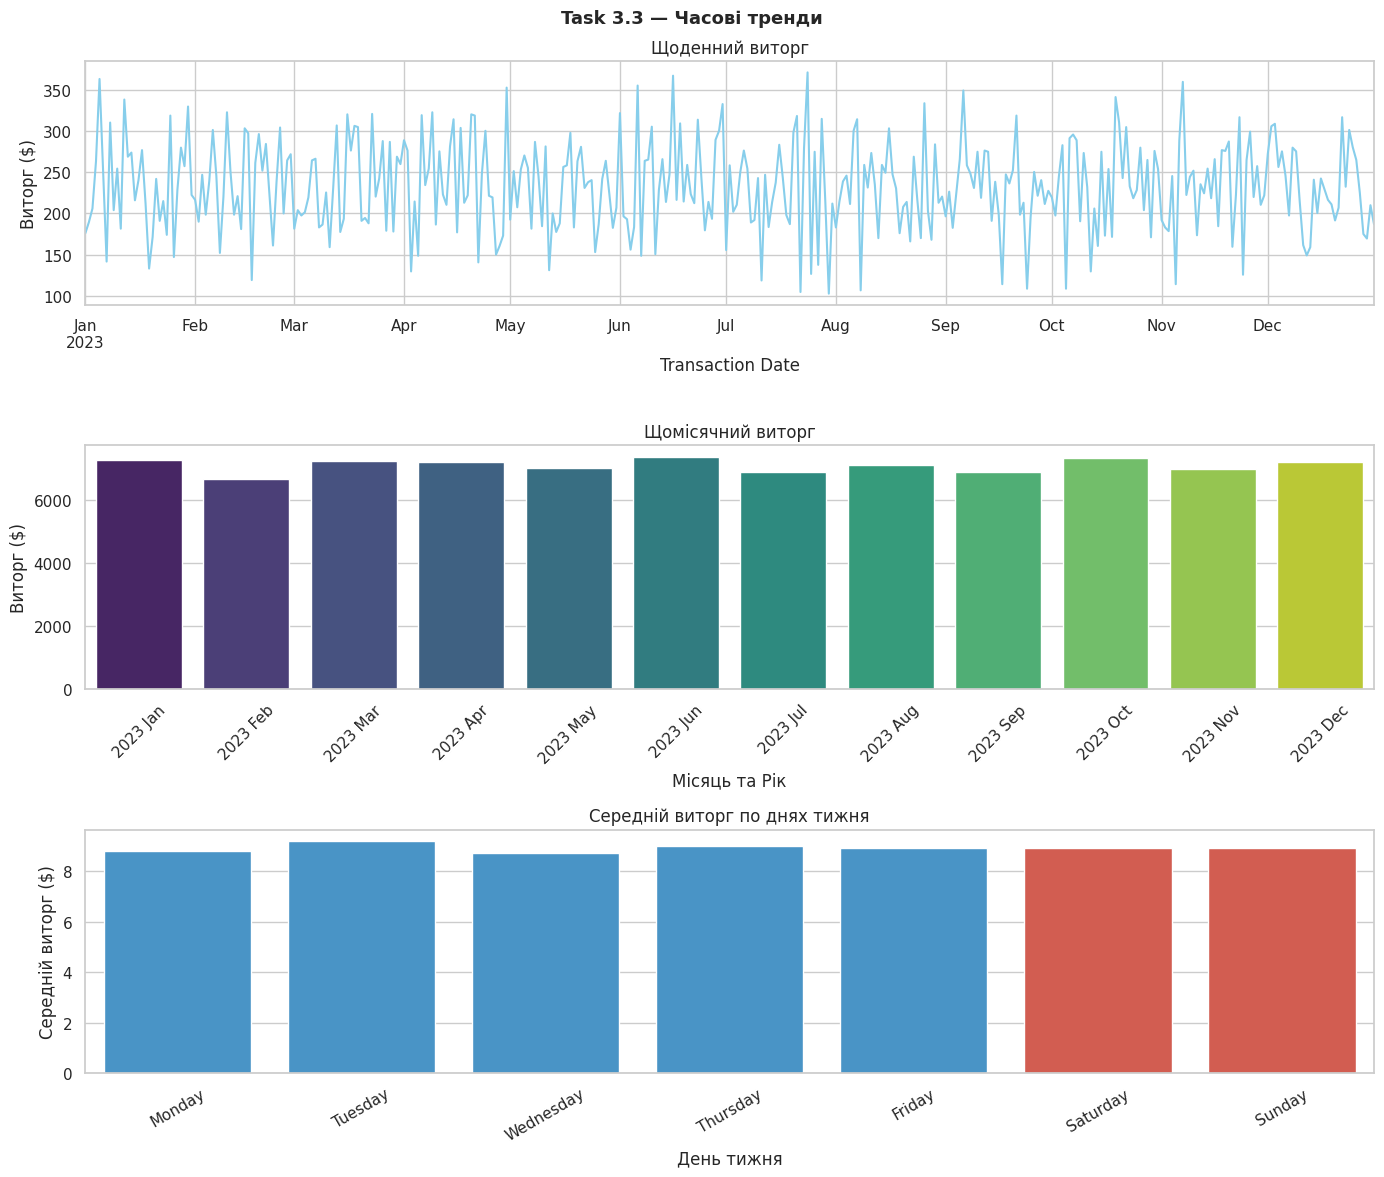

Місяць з найнижчим виторгом: 2023-February


In [48]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Task 3.3 — Часові тренди', fontsize=13, fontweight='bold')

# Графік 1: щоденний лінійний
daily_rev.plot(ax=axes[0], color='skyblue')
axes[0].set_title('Щоденний виторг')
axes[0].set_ylabel('Виторг ($)')

# Графік 2: щомісячний бар
monthly_rev.index.names = ['year', 'month_name']
monthly_rev_df = monthly_rev.reset_index()


month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_rev_df['month_name'] = pd.Categorical(monthly_rev_df['month_name'], categories=month_order, ordered=True)
monthly_rev_df = monthly_rev_df.sort_values(by=['year', 'month_name'])

monthly_rev_df['label'] = monthly_rev_df.apply(lambda row: f'{row["year"]} {row["month_name"][:3]}', axis=1)
sns.barplot(x='label', y='Total Spent', data=monthly_rev_df, ax=axes[1], palette='viridis')
axes[1].set_title('Щомісячний виторг')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Місяць та Рік')
axes[1].set_ylabel('Виторг ($)')

# Графік 3: по днях тижня (вихідні = червоні, будні = сині)
colors_dow = ['#E74C3C' if d in ['Saturday','Sunday'] else '#3498DB' for d in avg_dow.index]
sns.barplot(x=avg_dow.index, y=avg_dow.values, ax=axes[2], palette=colors_dow)
axes[2].set_title('Середній виторг по днях тижня')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_xlabel('День тижня')
axes[2].set_ylabel('Середній виторг ($)')

plt.tight_layout()
plt.savefig('part3_task33.png', dpi=130, bbox_inches='tight')
plt.show()

# Знайти місяць з найнижчим виторгом
worst_month = monthly_rev.idxmin()
print(f'Місяць з найнижчим виторгом: {worst_month[0]}-{worst_month[1]}')

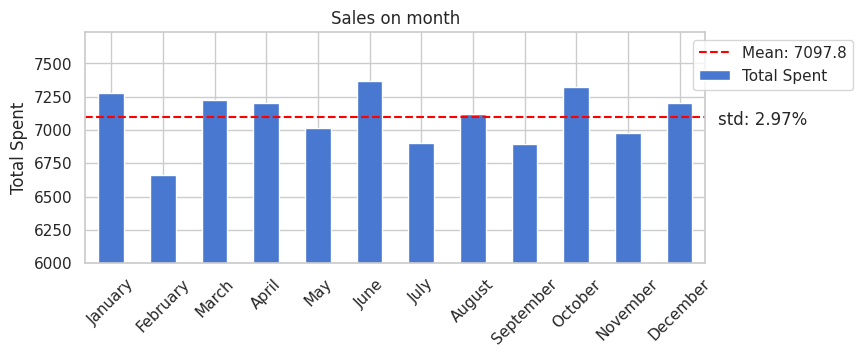

In [50]:
import matplotlib.pyplot as plt

# Продажі по місяцях побудова графіку
fig = plt.figure(figsize=(8,3))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# print(df.groupby('month_name')['Total Spent'].sum())


# Змінюємо послідовність місяців

rev_month = df.groupby('month_name')['Total Spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()]

)

rev_month.plot(kind='bar', rot=45)

mean_value = rev_month.mean()
std_value = rev_month.std()  # Стандартне відхилення
std_pct = (std_value / mean_value) * 100  #  Стандартне відхилення у %
# print(mean_value)
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_value:.1f}")

plt.ylim(bottom=6000)   # Змінюємо початок з 0 до 6000

plt.title("Sales on month")
plt.xlabel("")
plt.ylabel("Total Spent")
plt.legend(bbox_to_anchor=(1.25, 1),loc='upper right') # розміщення позначок

plt.text(1.02, 0.6, f"std: {std_pct:.2f}%", transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round, pad=0.3', facecolor='white', alpha=0.7)
         )  # оформлення підпису std: 2.80%
plt.show()

### ✏️ Висновок до Task 3.3

- Найкращий день тижня: Tuesday
- Найгірший місяць: February
- Є сезонний тренд? Сезонний тренд не спостерігається.

## Task 3.4 — Виявлення викидів

**Що потрібно:**
1. Побудувати boxplot для `quantity` і `total_spent`
2. Розрахувати межі викидів методом IQR
3. Порахувати кількість викидів
4. Прийняти рішення: видалити, залишити або кепувати

**Формули IQR:**
```
IQR = Q3 - Q1
Нижня межа = Q1 - 1.5 × IQR
Верхня межа = Q3 + 1.5 × IQR
```

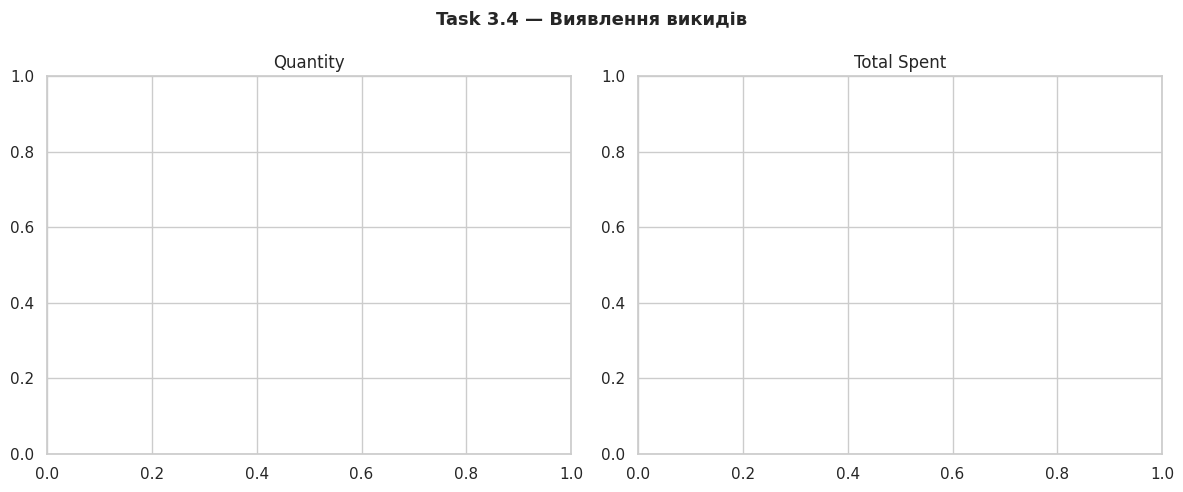

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3.4 — Виявлення викидів', fontsize=13, fontweight='bold')

# Boxplot для quantity
# Підказка: sns.boxplot(y=df['quantity'].astype(float), ax=axes[0], color='lightblue', ...)
# ВАШ КОД ТУТ
axes[0].set_title('Quantity')

# Boxplot для total_spent
# ВАШ КОД ТУТ
axes[1].set_title('Total Spent')

plt.tight_layout()
plt.savefig('part3_task34.png', dpi=130, bbox_inches='tight')
plt.show()

In [54]:
# Кількісний аналіз викидів методом IQR
Q1  = df['Total Spent'].quantile(0.25)
Q3  = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

low  = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

n_outliers = df[(df['Total Spent'] < low) | (df['Total Spent'] > high)].shape[0]

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Нормальний діапазон: [{low:.2f}, {high:.2f}]')
print(f'Кількість викидів: {n_outliers}')

Q1=4.00, Q3=12.00, IQR=8.00
Нормальний діапазон: [-8.00, 24.00]
Кількість викидів: 259


### ✏️ Рішення щодо викидів
*(Напишіть своє рішення та обгрунтування)*

**Рішення:** залишити викиди

**Обгрунтування:** Було виявлено 259 викидів. Ці викиди представляють транзакції з вищим, ніж зазвичай, виторгом.  Видалення або обмеження цих значень може спотворити аналіз, тому краще залишити викиди для збереження цілісності даних.

## Task 3.5 — Кореляційний аналіз

**Що потрібно:**
1. Порахувати кореляційну матрицю для `quantity`, `price_per_unit`, `total_spent`
2. Побудувати heatmap
3. Інтерпретувати результати

**Підказка:** `df[cols].astype(float).corr()`

Кореляційна матриця:
                quantity  Price Per Unit  Total Spent
quantity           1.000           0.008        0.706
Price Per Unit     0.008           1.000        0.646
Total Spent        0.706           0.646        1.000


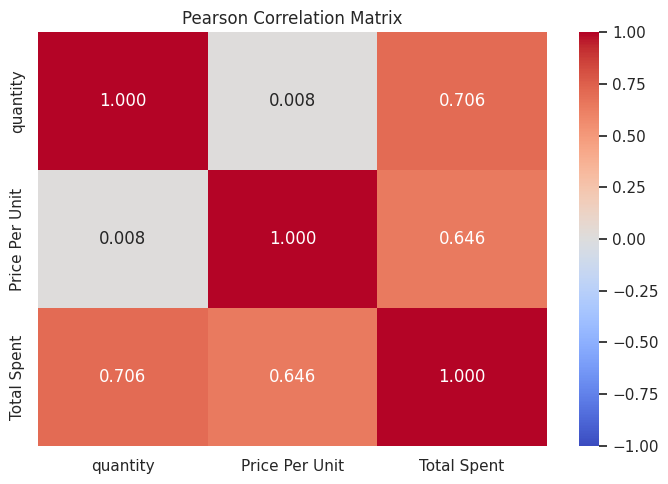

In [56]:
corr_cols   = ['quantity', 'Price Per Unit', 'Total Spent']
corr_matrix = df[corr_cols].corr()

print('Кореляційна матриця:')
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

# Heatmap кореляцій
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.savefig('part3_task35.png', dpi=130, bbox_inches='tight')
plt.show()

### ✏️ Інтерпретація кореляцій

| Пара | Значення | Сила | Пояснення |
|------|----------|------|-----------|
| total_spent ↔ quantity | 0.706 | Сильна позитивна | Зі збільшенням кількості куплених товарів (quantity) значно зростає загальна сума витрат (total_spent). Це логічно, оскільки більше товарів зазвичай означає вищий чек. |
| total_spent ↔ price_per_unit | 0.646 | Сильна позитивна | Зі збільшенням ціни за одиницю товару (price_per_unit) також значно зростає загальна сума витрат (total_spent). Це також очікуваний зв'язок, дорожчі товари призводять до вищого виторгу. |
| quantity ↔ price_per_unit | 0.008 | Дуже слабка позитивна | Практично відсутня кореляція між кількістю проданих товарів (quantity) та ціною за одиницю (price_per_unit). Це означає, що кількість куплених товарів не залежить значно від їхньої ціни за одиницю. |


---
# ЧАСТИНА 4 — Висновки та рекомендації

---

In [58]:
# Зберіть всі ключові метрики і надрукуйте підсумковий звіт

top_item_rev  = top_rev.index[0]  # найприбутковіший товар
top_item_qty  = top_qty.index[0]  # найпопулярніший за кількістю
top_pay       = rev_pay.idxmax()  # домінуючий спосіб оплати
top_loc       = rev_loc.idxmax()  # топ локація
total_revenue = df['Total Spent'].sum() # загальний виторг
avg_check     = df['Total Spent'].mean() # середній чек

print('=' * 55)
print('  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ')
print('=' * 55)

# Напишіть свій звіт тут — власними словами!
print(f"Загальний виторг за період: {total_revenue:.2f} $")
print(f"Середній чек: {avg_check:.2f} $")
print(f"Найприбутковіший товар: '{top_item_rev}'")
print(f"Найпопулярніший товар за кількістю: '{top_item_qty}'")
print(f"Домінуючий спосіб оплати: '{top_pay}' (проте варто дослідити категорію 'Unknown')")
print(f"Топ локація: '{top_loc}' (проте варто дослідити категорію 'Unknown')")
print(f"Найкращий день тижня для продажів: {avg_dow.idxmax()}")
print(f"Місяць з найнижчим виторгом: {worst_month[1]} {worst_month[0]}")
print("\nРекомендації:")
print("- Продовжувати моніторинг найбільш прибуткових та популярних товарів для оптимізації асортименту.")
print("- Детальніше проаналізувати транзакції з 'Unknown' способом оплати та локацією для кращого розуміння клієнтів.")
print("- Розглянути можливість проведення акцій у місяці з низьким виторгом (лютий) для стимулювання продажів.")
print('=' * 55)

  ЗВІТ ДЛЯ ВЛАСНИКА КАФЕ
Загальний виторг за період: 85173.00 $
Середній чек: 8.93 $
Найприбутковіший товар: 'Salad'
Найпопулярніший товар за кількістю: 'Juice'
Домінуючий спосіб оплати: 'Unknown' (проте варто дослідити категорію 'Unknown')
Топ локація: 'Unknown' (проте варто дослідити категорію 'Unknown')
Найкращий день тижня для продажів: Tuesday
Місяць з найнижчим виторгом: February 2023

Рекомендації:
- Продовжувати моніторинг найбільш прибуткових та популярних товарів для оптимізації асортименту.
- Детальніше проаналізувати транзакції з 'Unknown' способом оплати та локацією для кращого розуміння клієнтів.
- Розглянути можливість проведення акцій у місяці з низьким виторгом (лютий) для стимулювання продажів.


## ✅ Фінальний чеклист

Поставте ✓ навпроти кожного виконаного пункту:

**Частина 1**
- [х] Завантажено і оглянуто датасет
- [х] Знайдено і видалено дублікати
- [х] Порахована і візуалізована кількість пропусків

**Частина 2**
- [х] Перейменовано колонки
- [х] Замінено ERROR/UNKNOWN на NaN
- [х] Заповнено пропуски payment_method і location
- [х] Конвертовано типи даних
- [х] Побудовано словник ITEM_PRICE з даних
- [х] Оброблено три ситуації item/price
- [х] Відновлено quantity (через total/price або медіана по товару)
- [х] Відновлено total_spent, перевірено збіг і перезаписано розбіжності
- [х] Стандартизовано текст
- [х] Додано часові ознаки
- [х] Збережено FILE_OUT

**Частина 3**
- [х] Task 3.1: топ товари — два бар-чарти
- [х] Task 3.2: оплата і локація — pie + bar
- [х] Task 3.3: часові тренди — 3 графіки
- [х] Task 3.4: boxplot + IQR аналіз
- [х] Task 3.5: кореляційна матриця + heatmap

**Частина 4**
- [х] Підсумковий звіт з конкретними числами
- [х] Мінімум 1 бізнес-рекомендація

---
**🎉 Вітаємо з завершенням проєкту!**